# LIBRARY

In [68]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree
import json
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from collections import Counter
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from sklearn.metrics import precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

In [69]:
file_path = "../1.DATASET/CMI_FINAL_OD.csv"
df=pd.read_csv(file_path)

In [70]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']

X = df[attributes].values
X = df[attributes].values
y = np.array(df['sii'])

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")


X shape : (8396, 17)
y shape : (8396,)
Classes : [0. 1. 2. 3.]
Class counts : {0.0: 5801, 1.0: 1570, 2.0: 941, 3.0: 84}


In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

In [72]:
print(f"Class counts : {dict(zip(*np.unique(y_train, return_counts=True)))}")

Class counts : {0.0: 4060, 1.0: 1099, 2.0: 659, 3.0: 59}


In [73]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Random forest

In [74]:
def feature_imp(rand_forest, feature_names):
    nbr_features = len(feature_names)

    tree_feature_importances = rand_forest.feature_importances_
    sorted_idx = tree_feature_importances.argsort()[-nbr_features:]

    y_ticks = np.arange(len(sorted_idx))

    fig, ax = plt.subplots()

    ax.barh(y_ticks, tree_feature_importances[sorted_idx])
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(np.array(feature_names)[sorted_idx])

    ax.set_title("Random Forest Feature Importances")

    plt.show()

In [75]:
def plot_roc_curve(X_test, y_test, best_model):    
# Predizioni probabilistiche
    y_score = best_model.predict_proba(X_test)

    # Classi
    classes = np.unique(y_test)

    # Binarizzazione delle etichette
    y_test_bin = label_binarize(y_test, classes=classes)

    # Plot
    plt.figure(figsize=(8,6))

    for i, class_name in enumerate(classes):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f'Classe {class_name} (AUC = {roc_auc:.3f})'
        )

    # Linea casuale
    plt.plot([0, 1], [0, 1], 'k--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC Curve')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.show()

In [76]:
# ── Parametri globali ────────────────────────────────────────────────────────
random_state = 42
n_splits     = 5
n_iter       = 50

# ── Spazio di ricerca ────────────────────────────────────────────────────────
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [5, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['log2', 'sqrt'],
    'criterion':         ['gini', 'entropy'],
}

In [77]:
# ── Random Search ────────────────────────────────────────────────────────────
print("=" * 60)
print("  RANDOM SEARCH — Random Forest")
print("=" * 60)

random_search = RandomizedSearchCV(
    RandomForestClassifier(
        class_weight='balanced_subsample',  # fisso, sempre garantito
        random_state=random_state,
        n_jobs=-1,
    ),
    param_distributions=param_dist,
    cv=StratifiedKFold(                     # fondamentale con classi sbilanciate
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    ),
    scoring='f1_macro',                     # equo per classi sbilanciate
    n_jobs=-1,
    refit=True,
    n_iter=n_iter,
    random_state=random_state,
    verbose=1,
)

random_search.fit(X_train, y_train)

  RANDOM SEARCH — Random Forest
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(class_weight='balanced_subsample',
                                                    n_jobs=-1,
                                                    random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [5, 7, 10, 15],
                                        'max_features': ['log2', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='f1_macro', verbose=1)


── Best hyperparameters found ──────────────────────────
  n_estimators        : 100
  min_samples_split   : 10
  min_samples_leaf    : 4
  max_features        : log2
  max_depth           : 10
  criterion           : gini

  F1-macro (CV): 0.3350

── Classification Report (Test set) ───────────────────
              precision    recall  f1-score   support

         0.0       0.77      0.67      0.71      1741
         1.0       0.27      0.25      0.26       471
         2.0       0.18      0.35      0.24       282
         3.0       0.04      0.04      0.04        25

    accuracy                           0.55      2519
   macro avg       0.32      0.33      0.31      2519
weighted avg       0.60      0.55      0.57      2519

  F1-macro (Test):  0.3139
  F1-macro (CV):    0.3350
  Delta CV→Test:    -0.0211  (ok)


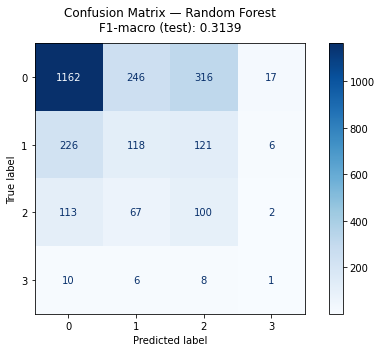

In [78]:
# ── Risultati della ricerca ──────────────────────────────────────────────────
print("\n── Best hyperparameters found ──────────────────────────")
for param, value in random_search.best_params_.items():
    print(f"  {param:<20}: {value}")
print(f"\n  F1-macro (CV): {random_search.best_score_:.4f}")

# ── Modello migliore ─────────────────────────────────────────────────────────
best_model = random_search.best_estimator_



# ── Previsioni sul test set ──────────────────────────────────────────────────
y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)

# ── Metriche ─────────────────────────────────────────────────────────────────
print("\n── Classification Report (Test set) ───────────────────")
print(classification_report(y_test, y_pred))

f1_test  = f1_score(y_test, y_pred, average='macro')
f1_cv    = random_search.best_score_
delta    = f1_test - f1_cv

print(f"  F1-macro (Test):  {f1_test:.4f}")
print(f"  F1-macro (CV):    {f1_cv:.4f}")
print(f"  Delta CV→Test:    {delta:+.4f}  "
      f"{'(ok)' if abs(delta) < 0.05 else '(attenzione: possibile overfitting)'}")

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(
    ax=ax, colorbar=True, cmap='Blues'
)
ax.set_title(
    f"Confusion Matrix — Random Forest\nF1-macro (test): {f1_test:.4f}",
    fontsize=12, pad=12,
)
plt.tight_layout()
plt.show()

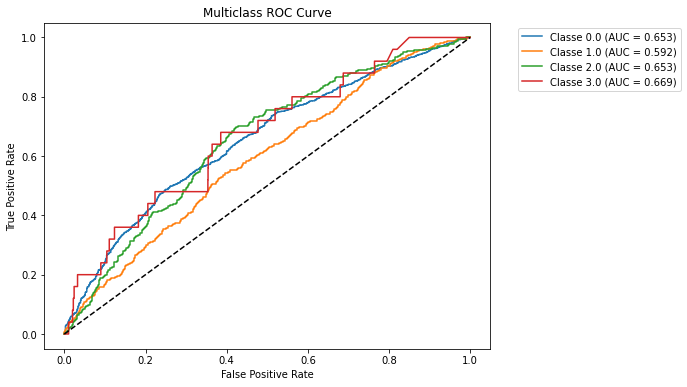

In [79]:
plot_roc_curve(X_test, y_test, best_model)

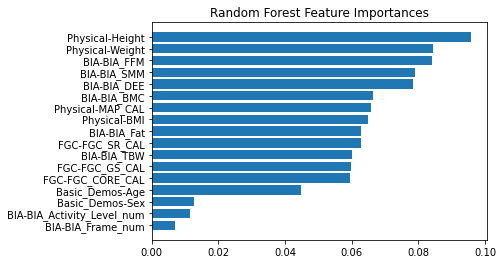

In [80]:
feature_imp(best_model, attributes)

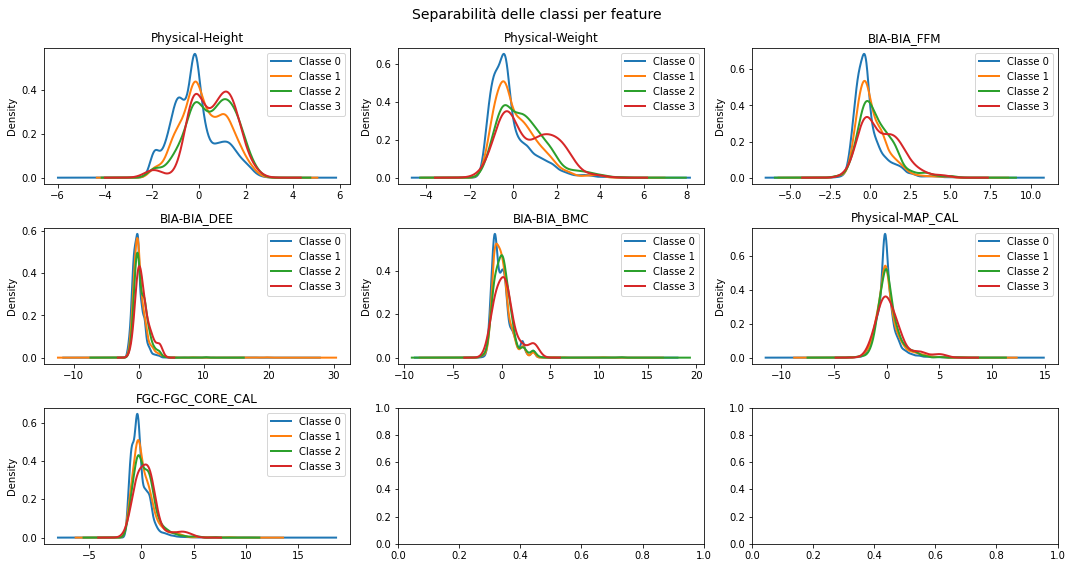

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

# Converte in DataFrame se necessario
X_train_df = pd.DataFrame(X_train, columns=attributes)

top_features = [
    'Physical-Height',
    'Physical-Weight',
    'BIA-BIA_FFM',
    'BIA-BIA_DEE',
    'BIA-BIA_BMC',
    'Physical-MAP_CAL',
    "FGC-FGC_CORE_CAL"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):

    for cls in [0, 1, 2, 3]:

        subset = X_train_df[y_train == cls][feat]

        subset.plot(
            kind='kde',
            ax=axes[i],
            label=f'Classe {cls}',
            linewidth=2
        )

    axes[i].set_title(feat)
    axes[i].legend()

plt.suptitle("Separabilità delle classi per feature", fontsize=14)
plt.tight_layout()
plt.show()

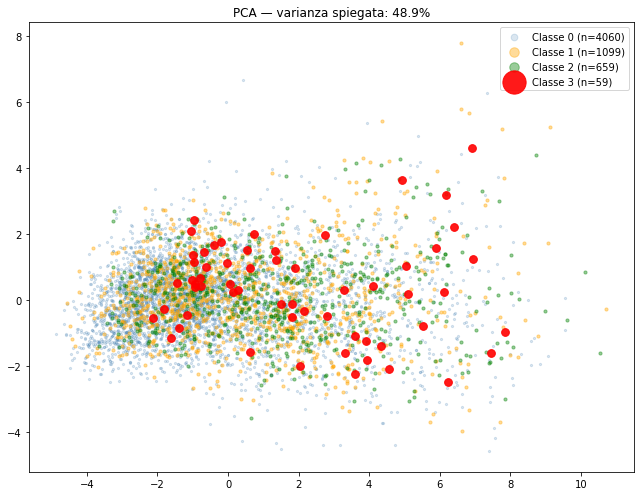

In [82]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train)

fig, ax = plt.subplots(figsize=(9, 7))
colors = {0: 'steelblue', 1: 'orange', 2: 'green', 3: 'red'}
sizes  = {0: 5, 1: 10, 2: 10, 3: 60}   # classe 3 più visibile
alphas = {0: 0.2, 1: 0.4, 2: 0.4, 3: 0.9}

for cls in [0, 1, 2, 3]:
    mask = y_train == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[cls], label=f'Classe {cls} (n={mask.sum()})',
               s=sizes[cls], alpha=alphas[cls])

ax.set_title(f"PCA — varianza spiegata: {pca.explained_variance_ratio_.sum():.1%}")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

# Random forest Cascade Model

## model

In [35]:
def plot_random_forest(rand_forest, feature_names):
    nbr_features = len(feature_names)

    tree_feature_importances = rand_forest.feature_importances_
    sorted_idx = tree_feature_importances.argsort()[-nbr_features:]

    y_ticks = np.arange(len(sorted_idx))

    fig, ax = plt.subplots()

    ax.barh(y_ticks, tree_feature_importances[sorted_idx])
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(np.array(feature_names)[sorted_idx])

    ax.set_title("Random Forest Feature Importances")

    plt.show()

In [26]:
def train_one_step_rf(X_train, y_binary, X_test, y_test_binary, step_name,
                      n_iter=30, n_splits=5, random_state=0):

    print(f"\n{'='*60}")
    print(f"  STEP: {step_name}")
    print(f"  Training samples : {len(y_binary)}")
    print(f"  Positive class   : {y_binary.sum()} samples")
    print(f"  Negative class   : {(y_binary==0).sum()} samples")
    print(f"{'='*60}")

    """param_list = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 4, 5, 7, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 5],
        'max_features': ['log2', 'sqrt'],
        'class_weight': ['balanced', None],
        'criterion': ['gini', 'entropy']
    }"""

    param_list = {
    'n_estimators': [100, 200, 300, 500],           # più alberi aiutano con classi rare
    'max_depth': [5, 7, 10, 15],#, None],         # alberi più profondi per pattern complessi
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],             # tolto 5: troppo alto per classe 3 (100 righe)
    'max_features': ['log2', 'sqrt'],
    'class_weight': ['balanced', 'balanced_subsample'],  # tolto None
    'criterion': ['gini', 'entropy']
    }

    random_search = RandomizedSearchCV(
        RandomForestClassifier(random_state=random_state),
        param_distributions=param_list,
        cv=KFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring='f1_macro',
        n_jobs=-1,
        refit=True,
        n_iter=n_iter,
        random_state=random_state
    )

    random_search.fit(X_train, y_binary)
    best_model = random_search.best_estimator_

    print(f"\n  Best params : {random_search.best_params_}")
    print(f"  Best CV F1  : {random_search.best_score_:.4f}")

    y_pred_binary = best_model.predict(X_test)
    y_proba       = best_model.predict_proba(X_test)[:, 1]

    test_f1 = f1_score(y_test_binary, y_pred_binary, average='weighted')
    print(f"  Test F1     : {test_f1:.4f}")

    cm = confusion_matrix(y_test_binary, y_pred_binary)
    disp = ConfusionMatrixDisplay(cm, display_labels=[f'not {step_name}', step_name])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {step_name}')
    plt.show()


    print(classification_report(y_test_binary, y_pred_binary,
                                target_names=[f'not {step_name}', step_name]))
    
    plot_random_forest(best_model, attributes) #feature importance

    return best_model


In [27]:
def print_dist(y, title='', binary=False):

    print(f"\n--- {title} ---")
    counts = Counter(y)

    if binary:
        print(f"0 → {counts.get(0, 0)} samples")
        print(f"1 → {counts.get(1, 0)} samples")
    else:
        for cls in sorted(counts.keys()):
            print(f"Class {cls}: {counts[cls]} samples")

    print(f"Total: {len(y)} samples")


In [28]:
step_results = {}   
y_pred_final = np.full(len(X_test), -1)
original_idx = np.arange(len(X_test))

# Working copies that shrink at each cascade step
X_tr = X_train.copy()
y_tr = y_train.copy()
X_te = X_test.copy()
y_te = y_test.copy()

models  = {}
classes = np.unique(y_train)

print(f"Classes found  : {classes}")
print(f"Train samples  : {len(y_tr)}")
print(f"Test samples   : {len(y_te)}")

Classes found  : [0. 1. 2. 3.]
Train samples  : 5877
Test samples   : 2519


In [29]:
print_dist(y_tr, 'TRAIN')
print_dist(y_te, 'TEST')


--- TRAIN ---
Class 0.0: 4060 samples
Class 1.0: 1099 samples
Class 2.0: 659 samples
Class 3.0: 59 samples
Total: 5877 samples

--- TEST ---
Class 0.0: 1741 samples
Class 1.0: 471 samples
Class 2.0: 282 samples
Class 3.0: 25 samples
Total: 2519 samples


## Class 0


In [30]:
# STEP 1: sii=0 vs [1, 2, 3] 
y_binary_tr = (y_tr == 0).astype(int)
y_binary_te = (y_te == 0).astype(int)


In [31]:
print_dist(y_binary_tr, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


--- TRAIN — binary step 1 ---
0 → 1817 samples
1 → 4060 samples
Total: 5877 samples

--- TEST  — binary step 1 ---
0 → 778 samples
1 → 1741 samples
Total: 2519 samples


In [32]:
over_dic={0:2500}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 4060, 0: 2500})


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [33]:
print_dist(y_res, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


--- TRAIN — binary step 1 ---
0 → 2500 samples
1 → 4060 samples
Total: 6560 samples

--- TEST  — binary step 1 ---
0 → 778 samples
1 → 1741 samples
Total: 2519 samples



  STEP: sii=0
  Training samples : 6560
  Positive class   : 4060 samples
  Negative class   : 2500 samples

  Best params : {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 15, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}
  Best CV F1  : 0.6817
  Test F1     : 0.6591


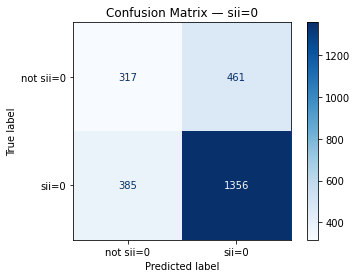

              precision    recall  f1-score   support

   not sii=0       0.45      0.41      0.43       778
       sii=0       0.75      0.78      0.76      1741

    accuracy                           0.66      2519
   macro avg       0.60      0.59      0.60      2519
weighted avg       0.66      0.66      0.66      2519



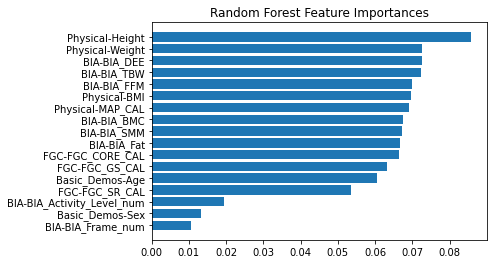

In [36]:
models[0] = train_one_step_rf(X_res, y_res, X_te, y_binary_te, step_name='sii=0')


In [37]:
# samples predicted as sii=0 → assign 0 to their original position
y_pred_te   = models[0].predict(X_test)

#----------------------------------
step_results[0] = {
    'step_name':    'sii=0 vs [1,2,3]',
    'y_true_bin':   y_binary_te.copy(),      # verdadero binario
    'y_pred_bin':   y_pred_te.copy(),        # predicho binario
    'y_true_orig':  y_test.copy(),             # verdadero multiclass en este paso
    'original_idx': original_idx.copy(),     # índices originales
}

y_pred_final[original_idx[y_pred_te == 1]] = 0

print(f"\n  Assigned as sii=0 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=0 : 1817 samples


## Class 1

In [38]:
# TRAIN → remove all true sii=0 
mask_tr      = y_tr != 0
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink index tracker too

In [39]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 1')
print_dist(y_te, 'TEST  after step 1')

  Remaining train : 1817
  Remaining test  : 1163

--- TRAIN after step 1 ---
Class 1.0: 1099 samples
Class 2.0: 659 samples
Class 3.0: 59 samples
Total: 1817 samples

--- TEST  after step 1 ---
Class 0.0: 385 samples
Class 1.0: 471 samples
Class 2.0: 282 samples
Class 3.0: 25 samples
Total: 1163 samples


In [40]:
y_binary_tr = (y_tr == 1).astype(int)
y_binary_te = (y_te == 1).astype(int)

In [41]:
print_dist(y_binary_tr, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


--- TRAIN — binary step 2 ---
0 → 718 samples
1 → 1099 samples
Total: 1817 samples

--- TEST  — binary step 2 ---
0 → 692 samples
1 → 471 samples
Total: 1163 samples


In [42]:
over_dic={0:800}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 1099, 0: 800})


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [43]:
print_dist(y_res, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


--- TRAIN — binary step 2 ---
0 → 800 samples
1 → 1099 samples
Total: 1899 samples

--- TEST  — binary step 2 ---
0 → 692 samples
1 → 471 samples
Total: 1163 samples



  STEP: sii=1
  Training samples : 1899
  Positive class   : 1099 samples
  Negative class   : 800 samples



  Best params : {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 7, 'criterion': 'gini', 'class_weight': 'balanced_subsample'}
  Best CV F1  : 0.5931
  Test F1     : 0.6022


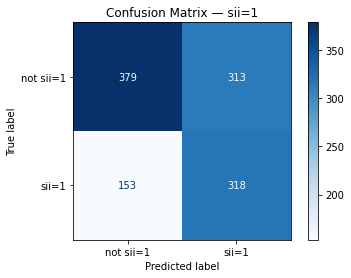

              precision    recall  f1-score   support

   not sii=1       0.71      0.55      0.62       692
       sii=1       0.50      0.68      0.58       471

    accuracy                           0.60      1163
   macro avg       0.61      0.61      0.60      1163
weighted avg       0.63      0.60      0.60      1163



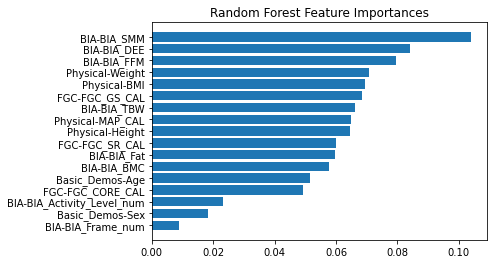

In [44]:
models[1] = train_one_step_rf(X_res, y_res, X_te, y_binary_te, step_name='sii=1')

In [45]:
y_pred_te   = models[1].predict(X_te)

step_results[1] = {
    'step_name':    'sii=1 vs [2,3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 1

print(f"\n  Assigned as sii=1 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=1 : 631 samples


## Class 2

In [46]:
# TRAIN → remove all true sii=1
mask_tr      = y_tr != 1
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES 
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

In [47]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 2')
print_dist(y_te, 'TEST  after step 2')

  Remaining train : 718
  Remaining test  : 845

--- TRAIN after step 2 ---
Class 2.0: 659 samples
Class 3.0: 59 samples
Total: 718 samples

--- TEST  after step 2 ---
Class 0.0: 385 samples
Class 1.0: 153 samples
Class 2.0: 282 samples
Class 3.0: 25 samples
Total: 845 samples


In [48]:
y_binary_tr = (y_tr == 2).astype(int)
y_binary_te = (y_te == 2).astype(int)

In [49]:
print_dist(y_binary_tr, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


--- TRAIN — binary step 3 ---
0 → 59 samples
1 → 659 samples
Total: 718 samples

--- TEST  — binary step 3 ---
0 → 563 samples
1 → 282 samples
Total: 845 samples


In [50]:
over_dic={0:100}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
X_res, y_res = under.fit_resample(X_res, y_res)
print('Resampled dataset shape %s' % Counter(y_res))


Resampled dataset shape Counter({1: 645, 0: 100})


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [51]:
print_dist(y_res, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


--- TRAIN — binary step 3 ---
0 → 100 samples
1 → 645 samples
Total: 745 samples

--- TEST  — binary step 3 ---
0 → 563 samples
1 → 282 samples
Total: 845 samples



  STEP: sii=2
  Training samples : 745
  Positive class   : 645 samples
  Negative class   : 100 samples

  Best params : {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 7, 'criterion': 'gini', 'class_weight': 'balanced_subsample'}
  Best CV F1  : 0.7219
  Test F1     : 0.2663


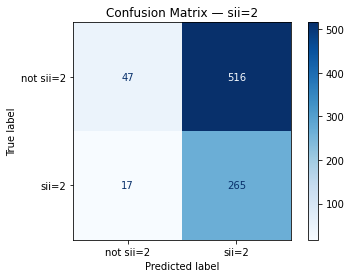

              precision    recall  f1-score   support

   not sii=2       0.73      0.08      0.15       563
       sii=2       0.34      0.94      0.50       282

    accuracy                           0.37       845
   macro avg       0.54      0.51      0.32       845
weighted avg       0.60      0.37      0.27       845



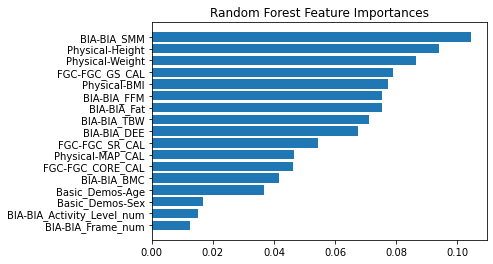

In [52]:
models[2] = train_one_step_rf(X_res, y_res, X_te, y_binary_te,
                            step_name='sii=2')

In [53]:
# ── Assign predictions for step 3 ────────────────────────────────────────────
y_pred_te   = models[2].predict(X_te)

step_results[2] = {
    'step_name':    'sii=2 vs [3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 2

print(f"\n  Assigned as sii=2 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=2 : 781 samples


## Class 3

In [54]:
# ── Filter for next step ──────────────────────────────────────────────────────
mask_tr      = y_tr != 2
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")

  Remaining train : 59
  Remaining test  : 580


In [55]:
y_pred_final[original_idx] = 3
step_results[3] = {
    'step_name':    'sii=3 (remaining)',
    'y_true_bin':   (y_te == 3).astype(int),
    'y_pred_bin':   np.ones(len(y_te), dtype=int),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

print(f"\n  Assigned as sii=3 : {len(original_idx)} samples (all remaining)")


  Assigned as sii=3 : 580 samples (all remaining)


## Final Result

In [56]:
# ══════════════════════════════════════════════════════════════════════════════
# REPORTE COMBINADO
# ══════════════════════════════════════════════════════════════════════════════


print("\n" + "="*75)
print("  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS")
print("="*75)

rows = []
for step, res in step_results.items():
    yt = res['y_true_bin']
    yp = res['y_pred_bin']

    # métricas binarias reales de cada paso
    prec   = precision_score(yt, yp, zero_division=0)
    rec    = recall_score(yt, yp, zero_division=0)
    f1     = f1_score(yt, yp, zero_division=0)
    n      = len(yt)
    n_pos  = yt.sum()
    tp     = ((yp == 1) & (yt == 1)).sum()
    fp     = ((yp == 1) & (yt == 0)).sum()
    fn     = ((yp == 0) & (yt == 1)).sum()

    rows.append({
        'Step':         res['step_name'],
        'N samples':    n,
        'N positive':   n_pos,
        'TP':           tp,
        'FP':           fp,
        'FN':           fn,
        'Precision':    round(prec, 4),
        'Recall':       round(rec,  4),
        'F1':           round(f1,   4),
    })

report_df = pd.DataFrame(rows)
print(report_df.to_string(index=False))


  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS
             Step  N samples  N positive   TP  FP  FN  Precision  Recall     F1
 sii=0 vs [1,2,3]       2519        1741 1356 461 385     0.7463  0.7789 0.7622
   sii=1 vs [2,3]       1163         471  318 313 153     0.5040  0.6752 0.5771
     sii=2 vs [3]        845         282  265 516  17     0.3393  0.9397 0.4986
sii=3 (remaining)        580          25   25 555   0     0.0431  1.0000 0.0826


In [57]:
# ── Multiclass final ──────────────────────────────────────────────────────────
print("\n" + "="*75)
print("  FINAL MULTICLASS REPORT (y_test vs y_pred_final)")
print("="*75)
print(classification_report(
    y_test, y_pred_final,
    target_names=['sii=0', 'sii=1', 'sii=2', 'sii=3']
))


  FINAL MULTICLASS REPORT (y_test vs y_pred_final)
              precision    recall  f1-score   support

       sii=0       1.00      0.78      0.88      1741
       sii=1       1.00      0.68      0.81       471
       sii=2       1.00      0.94      0.97       282
       sii=3       0.04      1.00      0.08        25

    accuracy                           0.78      2519
   macro avg       0.76      0.85      0.68      2519
weighted avg       0.99      0.78      0.87      2519



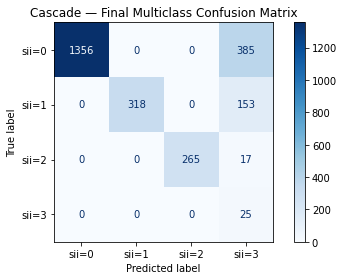

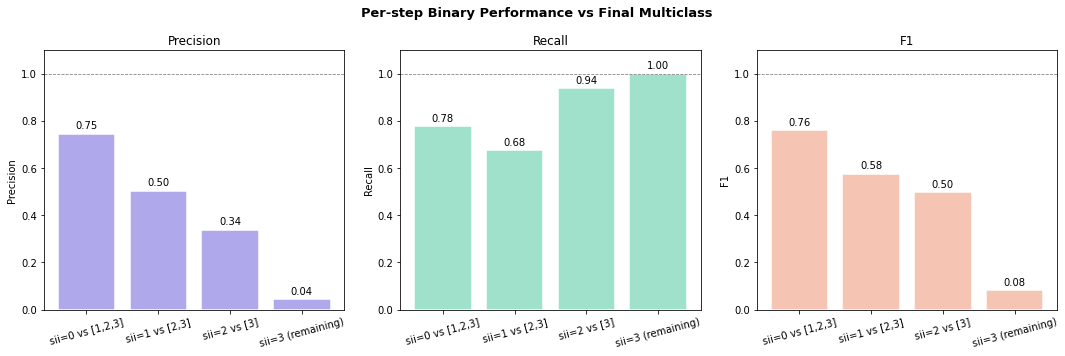

In [58]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_final, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['sii=0', 'sii=1', 'sii=2', 'sii=3']
)
disp.plot(cmap='Blues')
plt.title('Cascade — Final Multiclass Confusion Matrix')
plt.tight_layout()
plt.show()

# ── Plot comparativo ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics   = ['Precision', 'Recall', 'F1']
colors    = ['#AFA9EC', '#9FE1CB', '#F5C4B3']

for ax, metric, color in zip(axes, metrics, colors):
    steps  = [r['Step'] for r in rows]
    values = [r[metric] for r in rows]
    bars   = ax.bar(steps, values, color=color, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', fontsize=10)

plt.suptitle('Per-step Binary Performance vs Final Multiclass',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [59]:
# ── Per class summary ─────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  PREDICTIONS SUMMARY")
print(f"{'='*60}")
for cls in [0, 1, 2, 3]:
    true_count = (y_test == cls).sum()
    pred_count = (y_pred_final == cls).sum()
    print(f"  sii={cls} → true: {true_count:<6} predicted: {pred_count}")


  PREDICTIONS SUMMARY
  sii=0 → true: 1741   predicted: 1356
  sii=1 → true: 471    predicted: 318
  sii=2 → true: 282    predicted: 265
  sii=3 → true: 25     predicted: 580


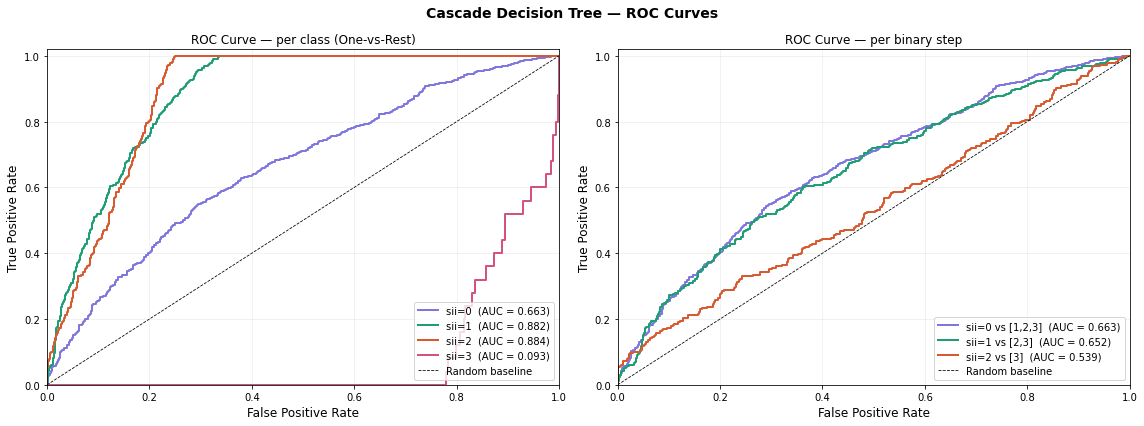


  AUC SUMMARY
  sii=0    → AUC = 0.6632
  sii=1    → AUC = 0.8823
  sii=2    → AUC = 0.8839
  sii=3    → AUC = 0.0930

  Macro AUC    : 0.6306
  Weighted AUC : 0.7232


In [60]:
# ── 1. Collect probabilities from each step ───────────────────────────────────
# Each model gives P(class=X) for the samples it saw
# We need to reconstruct full probability matrix (n_test, 4)

n_test     = len(X_test)
proba_full = np.zeros((n_test, 4))   # one column per class

for step, res in step_results.items():
    idx    = res['original_idx']          # which original test samples this step saw
    model  = models.get(step)

    if model is not None:
        proba_step         = model.predict_proba(X_test[idx])   # shape (n_step, 2)
        proba_full[idx, step] = proba_step[:, 1]                # P(positive) for this class
    else:
        # last class — use survival probability (1 - sum of previous)
        proba_full[idx, step] = 1 - proba_full[idx, :step].sum(axis=1)

# ── 2. Binarize y_test for multiclass ROC ────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])  # shape (n_test, 4)

# ── 3. Compute ROC per class ──────────────────────────────────────────────────
colors     = ['#7F77DD', '#1D9E75', '#D85A30', '#D4537E']
step_names = ['sii=0', 'sii=1', 'sii=2', 'sii=3']

fpr_dict = {}
tpr_dict = {}
auc_dict = {}

for i in range(4):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], proba_full[:, i])
    auc_dict[i]                  = auc(fpr_dict[i], tpr_dict[i])

# ── 4. Plot — two panels ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1 — individual ROC per class ───────────────────────────────────────
ax = axes[0]
for i in range(4):
    ax.plot(fpr_dict[i], tpr_dict[i],
            color=colors[i],
            linewidth=2,
            label=f"{step_names[i]}  (AUC = {auc_dict[i]:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per class (One-vs-Rest)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

# ── Panel 2 — step by step binary ROC ────────────────────────────────────────
ax = axes[1]
for step, res in step_results.items():
    model = models.get(step)
    if model is None:
        continue                              # skip last class (no model)

    idx        = res['original_idx']
    y_true_bin = res['y_true_bin']
    y_proba    = model.predict_proba(X_test[idx])[:, 1]

    fpr, tpr, _ = roc_curve(y_true_bin, y_proba)
    roc_auc     = auc(fpr, tpr)

    ax.plot(fpr, tpr,
            color=colors[step],
            linewidth=2,
            label=f"{step_results[step]['step_name']}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per binary step', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

plt.suptitle('Cascade Decision Tree — ROC Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5. Print AUC summary ──────────────────────────────────────────────────────
print("\n" + "="*45)
print("  AUC SUMMARY")
print("="*45)
for i in range(4):
    print(f"  {step_names[i]:<8} → AUC = {auc_dict[i]:.4f}")

macro    = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='macro')
weighted = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='weighted')
print(f"\n  Macro AUC    : {macro:.4f}")
print(f"  Weighted AUC : {weighted:.4f}")
print("="*45)